In [34]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from MDAnalysis.analysis.rdf import InterRDF
import MDAnalysis as mda
from MDAnalysis.analysis import rdf

from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
import h5py

In [7]:
# Color mapping for sizes
size_colors = {'small': '#e74c3c', 'medium': '#27ae60', 'large': '#f39c12'}
marker_styles = {'grace': 'o', 'mace': 's', 'experiment': 'X'}

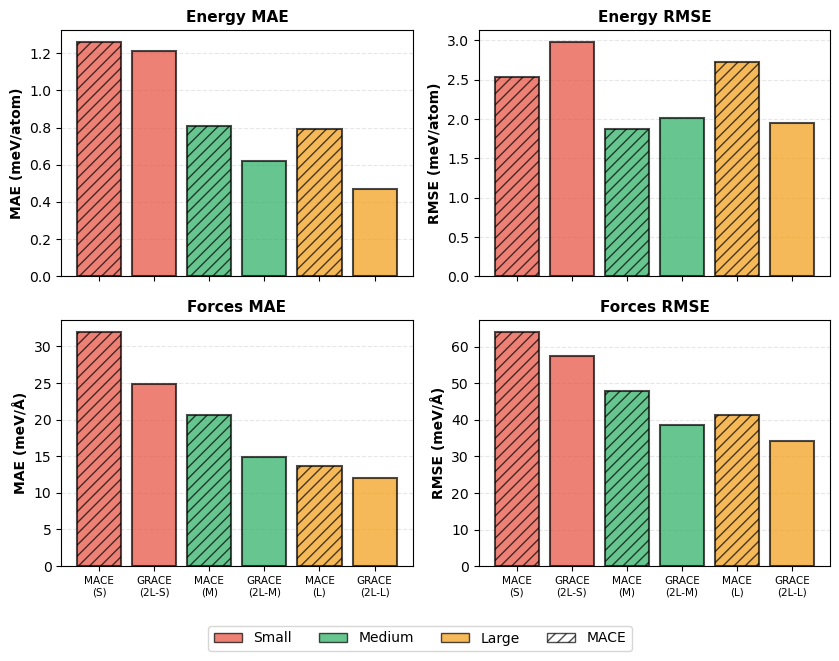

In [3]:
##### Final Plots for Energies and Forces #####

# Load data
# There are two possible files, energies_per_atom -> structures seen by GRACE and MACE, energies_per_atom_ood -> structure NOT seen by GRACE
df = pd.read_csv('energies/energies_per_atom.csv')

df["model"] = df["model"].str.upper()
df["size"] = df["size"].replace("2l_small", "(2L-S)")
df["size"] = df["size"].replace("2l_medium", "(2L-M)")
df["size"] = df["size"].replace("2l_large", "(2L-L)")
df["size"] = df["size"].replace("1l_small", "(1L-S)")
df["size"] = df["size"].replace("1l_medium", "(1L-M)")
df["size"] = df["size"].replace("1l_large", "(1L-L)")

# Extract layers and model_size from the reformatted size column
df['layers'] = df['size'].str.extract(r'(\d+L)')[0].str.lower()
df['model_size'] = df['size']

# Filter for 2-layer models only (2l GRACE and MACE)
df = df[(df['layers'] == '2l') | (df['model'] == 'MACE')].copy()

# Sort order: group by size (small, medium, large), then within each size: GRACE first, then MACE
def get_sort_key(row):
    size_order = {'(2L-S)': 0, '(2L-M)': 1, '(2L-L)': 2}
    model_order = {'GRACE': 1, 'MACE': 0}  # MACE first, then GRACE
    return (size_order[row['model_size']], model_order[row['model']])

df['sort_keys'] = df.apply(get_sort_key, axis=1)
df = df.sort_values('sort_keys').reset_index(drop=True)
df = df.drop('sort_keys', axis=1)

# Create x-axis labels: include size and layer info
df['x_label'] = df.apply(
    lambda row: f"{row['model']}\n{row['model_size'].replace('2L-', '')}" if row['model'] == 'MACE' 
    else f"{row['model']}\n{row['model_size']}", 
    axis=1
)

# Create 2x2 subplot with shared x-axis
fig, axes = plt.subplots(2, 2, figsize=(8.5, 6.5), sharex=True)
axes = axes.flatten()

# Metrics to plot: (column_name, title, ylabel, unit)
metrics = [
    ('energy_mae_meV', 'Energy MAE', 'MAE (meV/atom)'),
    ('energy_rmse_meV', 'Energy RMSE', 'RMSE (meV/atom)'),
    ('forces_mae_meV_per_A', 'Forces MAE', 'MAE (meV/Å)'),
    ('forces_rmse_meV_per_A', 'Forces RMSE', 'RMSE (meV/Å)'),
]

# Plot each metric
for idx, (metric, title, ylabel) in enumerate(metrics):
    ax = axes[idx]
    
    # Get unique x positions
    x_positions = np.arange(len(df))
    
    # Create bars with colors based on size - map new format to color keys
    size_to_color = {'(2L-S)': 'small', '(2L-M)': 'medium', '(2L-L)': 'large',
                     '(1L-S)': 'small', '(1L-M)': 'medium', '(1L-L)': 'large'}
    colors = [size_colors[size_to_color[size]] for size in df['model_size']]
    
    # Highlight MACE models with hatching pattern
    hatches = ['///' if model == 'MACE' else '' for model in df['model']]
    
    bars = ax.bar(x_positions, df[metric], color=colors, alpha=0.7, 
                  edgecolor='black', linewidth=1.5)
    
    # Apply hatching to MACE bars
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    
    # Customize plot
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(df['x_label'], fontsize=7.5, rotation=0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

# Create legend for sizes and MACE pattern at the bottom
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=size_colors[size], label=size.capitalize(), 
                         edgecolor='black', alpha=0.7) 
                   for size in ['small', 'medium', 'large']]
# Add MACE hatching pattern to legend
legend_elements.append(Patch(facecolor='white', label='MACE', 
                             edgecolor='black', hatch='///', alpha=0.7))
fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
           bbox_to_anchor=(0.5, -0.02), fontsize=10, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("energies.pdf", bbox_inches='tight')
plt.show()

In [4]:
# Check the raw data first
df = pd.read_csv("condensed_phase/condensed_phase_summary_data.csv")

df.columns = ['solute', 'model', 'heat_of_vaporization', 
              'heat_capacity', 'compressibility',
              'thermal_expansion', 'density']

# Remove rows with missing solute
df_clean = df[df['solute'].notna()].copy()

# Standardize NMA capitalization
df_clean.loc[df_clean['solute'].str.lower() == 'nma', 'solute'] = 'NMA'

print(f"Unique solutes: {df_clean['solute'].unique()}")


Unique solutes: ['Water' 'Benzene' 'Hexane' 'Acetone' 'Methanol' 'NMA']


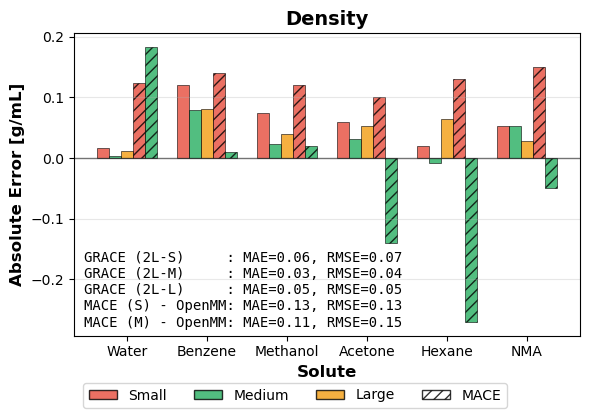

In [5]:
# Create bar plot showing difference to experimental values
fig, ax = plt.subplots(figsize=(6, 4))

# Get experimental data
exp_data = df_clean[df_clean["model"] == "experiment"]
# Include all models except experiment
model_data = df_clean[df_clean["model"] != "experiment"]


# Get unique solutes and models
solutes = exp_data["solute"].unique()
models = model_data["model"].unique()

# Calculate differences for each model and solute
differences_data = []

for model in models:
    model_subset = model_data[model_data["model"] == model]
    
    # Determine model size for color
    model_size = None
    if "(2L-S)" in model or "(S)" in model:
        model_size = "S"
    elif "(2L-M)" in model or "(M)" in model:
        model_size = "M"
    elif "(2L-L)" in model or "(L)" in model:
        model_size = "L"
    
    color = size_colors.get(model_size, "gray")
    
    for solute in solutes:
        exp_val = exp_data[exp_data["solute"] == solute]["density"].values
        mod_val = model_subset[model_subset["solute"] == solute]["density"].values
        
        if len(exp_val) > 0 and len(mod_val) > 0:
            exp_v = exp_val[0]
            mod_v = mod_val[0]
            
            if pd.notna(exp_v) and pd.notna(mod_v):
                diff = mod_v - exp_v
                differences_data.append({
                    'model': model,
                    'solute': solute,
                    'difference': diff,
                    'color': color
                })

# Create DataFrame for plotting
df_diff = pd.DataFrame(differences_data)

# Create grouped bar plot
x = np.arange(len(solutes))
width = 0.15
offsets = np.linspace(-width * (len(models)-1)/2, width * (len(models)-1)/2, len(models))

for i, model in enumerate(models):
    model_data_subset = df_diff[df_diff['model'] == model]
    values = []
    
    # Determine model size for color (once per model)
    model_size = None
    if "(2L-S)" in model or "(S)" in model:
        model_size = "small"
    elif "(2L-M)" in model or "(M)" in model:
        model_size = "medium"
    elif "(2L-L)" in model or "(L)" in model:
        model_size = "large"
    
    color = size_colors.get(model_size, "gray")
    
    for solute in solutes:
        solute_data = model_data_subset[model_data_subset['solute'] == solute]
        if len(solute_data) > 0:
            values.append(solute_data['difference'].values[0])
        else:
            values.append(0)
    
    # Calculate MAE for this model
    mae = np.mean(np.abs(values))
    
    # Add hatch pattern for MACE models
    hatch = '///' if 'MACE' in model else None
    
    ax.bar(x + offsets[i], values, width, 
           color=color, alpha=0.8, hatch=hatch, edgecolor='black', linewidth=0.5)

# Add zero line
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax.set_ylabel('Absolute Error [g/mL]', fontweight='bold', fontsize=12)
ax.set_title('Density', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(solutes, rotation=0)
ax.grid(axis='y', alpha=0.3)

# Add MAE and RMSE text annotations in bottom left
mae_rmse_text = []
# Find longest model name for alignment
max_len = max(len(model) for model in models)
for model in models:
    model_data_subset = df_diff[df_diff['model'] == model]
    values = []
    for solute in solutes:
        solute_data = model_data_subset[model_data_subset['solute'] == solute]
        if len(solute_data) > 0:
            values.append(solute_data['difference'].values[0])
        else:
            values.append(0)
    mae = np.mean(np.abs(values))
    rmse = np.sqrt(np.mean(np.array(values)**2))
    # Pad model name to align MAE/RMSE values
    mae_rmse_text.append(f"{model:<{max_len}}: MAE={mae:.2f}, RMSE={rmse:.2f}")

# Add text box with MAE and RMSE values in bottom left with white background
textstr = '\n'.join(mae_rmse_text)
props = dict(boxstyle='round', facecolor='white', alpha=0.1, edgecolor='white')
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', bbox=props, family='monospace')

ax.set_xlabel('Solute', fontweight='bold', fontsize=12)

# Create size and MACE pattern legend below the figure
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=size_colors['small'], label='Small', edgecolor='black', alpha=0.8),
    Patch(facecolor=size_colors['medium'], label='Medium', edgecolor='black', alpha=0.8),
    Patch(facecolor=size_colors['large'], label='Large', edgecolor='black', alpha=0.8),
    Patch(facecolor='white', label='MACE', edgecolor='black', hatch='///', alpha=0.8)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
           bbox_to_anchor=(0.5, -0.05), fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig("densities_all_solutes.pdf", bbox_inches='tight')
plt.show()

In [6]:
traj = {
    "GRACE (2L-S)": "traj/traj_water_npt_300_2l_grace_small.pdb",
    "GRACE (2L-M)": "traj/traj_water_npt_300_2l_grace_medium.pdb",
    "GRACE (2L-L)": "traj/traj_water_npt_300_2l_grace_large.pdb",
}


model_rdf = dict()

for model, path in traj.items():

    u = mda.Universe(path)

    irdf2 = dict()

    oxygen = u.select_atoms("name O*")
    hydrogen = u.select_atoms("name H*")

    for i, combination in enumerate(["o-o", "o-h", "h-h"]):
        if combination == "o-o":
            group1 = oxygen
            group2 = oxygen
            exclusion_block = (1, 1)
        elif combination == "o-h":
            group1 = oxygen
            group2 = hydrogen
            exclusion_block = (1, 2)
        elif combination == "h-h":
            group1 = hydrogen
            group2 = hydrogen
            exclusion_block = (2, 2)

        irdf2[combination] = InterRDF(
            group1,
            group2,
            nbins=75,  # default
            range=(0.0, 12.0),  # distance in angstroms
            exclusion_block=exclusion_block,  # exclude intramolecular pairs
        )
        irdf2[combination].run(step=100)

    model_rdf[path] = irdf2

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.11/site-packages/MDAnalysis/analysis/base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


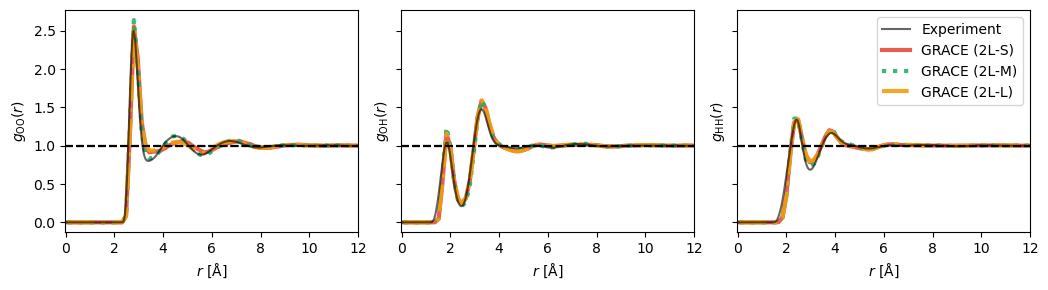

In [7]:
# water data ----------------------------------

exp_water = pd.read_csv("../data/exp_data/exp_water.dat", delimiter="\t")
r_A = exp_water[" r[A] "]
rdf_exp_OO = exp_water["O–O "]
rdf_exp_Oh = exp_water["O–H "]
rdf_exp_hh = exp_water["H–H "]
xlim_lower, xlim_upper = -0.2, 10

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3), sharey=True)
axes[0].plot(r_A, rdf_exp_OO, label="Experiment", color="black", linewidth=1.5, linestyle='-', zorder=10, alpha=0.6)
axes[1].plot(r_A, rdf_exp_Oh, label="Experiment", color="black", linewidth=1.5, linestyle='-', zorder=10, alpha=0.6)
axes[2].plot(r_A, rdf_exp_hh, label="Experiment", color="black", linewidth=1.5, linestyle='-', zorder=10, alpha=0.6)


ylabel_map = {"o-o": r"$g_{\mathrm{OO}}(r)$", "o-h": r"$g_{\mathrm{OH}}(r)$", "h-h": r"$g_{\mathrm{HH}}(r)$"}

# Extract size from model name for color mapping and assign different line styles
model_colors = {}
model_linestyles = {}
linestyles = ['-', ':', '-.', ':']  # solid, dashed, dash-dot, dotted
for idx, model in enumerate(traj.keys()):
    if 'S' in model:
        model_colors[model] = size_colors['small']
    elif 'M' in model:
        model_colors[model] = size_colors['medium']
    elif '2L-L' in model:
        model_colors[model] = size_colors['large']
    model_linestyles[model] = linestyles[idx % len(linestyles)]

for model, path in traj.items():
    rdf = model_rdf[path]
    for i, combination in enumerate(["o-o", "o-h", "h-h"]):

        axes[i].plot(
            rdf[combination].results.bins,
            rdf[combination].results.rdf,
            label=model,
            color=model_colors[model],
            linestyle=model_linestyles[model],
            alpha=0.9,
            linewidth=3.0,
        )
        axes[i].axhline(y=1, color="k", linestyle="--")
        axes[i].set_xlabel(r"$r$ [Å]")
        axes[i].set_ylabel(ylabel_map[combination])
        axes[i].set_xlim(-0.01, 12)
        axes[2].legend()


plt.tight_layout()
plt.savefig("waterbox_rdf.pdf")
plt.show()

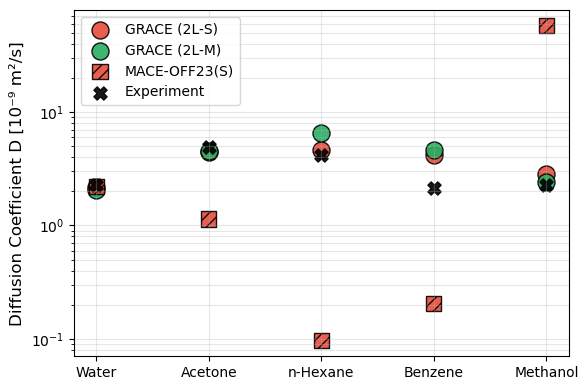

In [8]:
df_diffusion = pd.read_csv("diffusion/diffusion_results.csv")
df_diffusion["solute"] = df_diffusion["solute"].replace("Hexane", "n-Hexane")
df_diffusion["model"] = df_diffusion["model"].replace("GRACE SMALL", "GRACE (2L-S)")
df_diffusion["model"] = df_diffusion["model"].replace("GRACE MEDIUM", "GRACE (2L-M)")
df_diffusion_dropped = df_diffusion #.drop(16)


# Create a scatter plot with solutes on x-axis and models as different series
fig, ax = plt.subplots(figsize=(6, 4))

# Get unique models and solutes
models = df_diffusion_dropped['model'].unique()
solutes = df_diffusion_dropped['solute'].unique()

# Define colors and markers for different models
colors = {'GRACE (2L-S)': size_colors['small'], 'GRACE (2L-M)': size_colors['medium'], 'Experiment': 'black', 'MACE-OFF23(S)': size_colors['small']}
markers = {'GRACE (2L-S)': marker_styles['grace'], 'GRACE (2L-M)': marker_styles['grace'], 'Experiment': marker_styles['experiment'], 'MACE-OFF23(S)': marker_styles['mace']}

# Plot each model
for model in models:
    model_data = df_diffusion_dropped[df_diffusion_dropped['model'] == model]
    if "Experiment" in model:
        size = 90
    else:
        size = 150
    # Add hatch pattern for MACE models
    if 'MACE' in model:
        ax.scatter(model_data['solute'], model_data['D_m2_s']*10**9, 
                   label=model, 
                   color=colors.get(model, 'gray'),
                   marker=markers.get(model, 'o'),
                   edgecolors='black',
                   alpha=0.9,
                   s=120,
                   hatch='///')
    else:
        ax.scatter(model_data['solute'], model_data['D_m2_s']*10**9, 
                   label=model, 
                   color=colors.get(model, 'gray'),
                   marker=markers.get(model, 'o'),
                   edgecolors='black',
                   alpha=0.9,
                   s=size)

ax.set_ylabel('Diffusion Coefficient D [10⁻⁹ m²/s]', fontsize=12)
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
# ax.ticklabel_format(style='plain', axis='y')


plt.tight_layout()
plt.savefig("diffusion_values_all.pdf")

/tmp/ipykernel_2415292/1829200746.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv("rdf/rmsd_run1.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"])
/tmp/ipykernel_2415292/1829200746.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv("rdf/rmsd_run2.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"])
/tmp/ipykernel_2415292/1829200746.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df3 = pd.read_csv("rdf/rmsd_run3.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"])


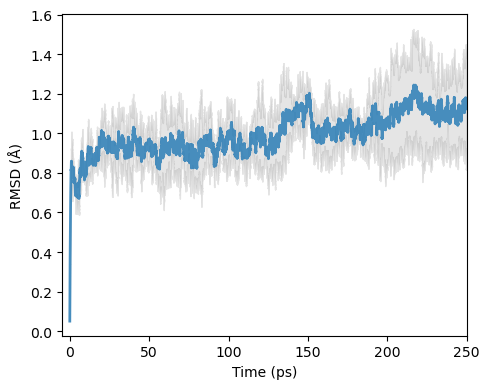

In [9]:
# Read data
df1 = pd.read_csv("rdf/rmsd_run1.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"])
df2 = pd.read_csv("rdf/rmsd_run2.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"])
df3 = pd.read_csv("rdf/rmsd_run3.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"])

# Combine data
frames = df1["frame"].values
rmsd1 = df1["rmsd"].values
rmsd2 = df2["rmsd"].values
rmsd3 = df3["rmsd"].values

# Calculate mean and standard deviation
rmsd_mean = (rmsd1 + rmsd2 + rmsd3) / 3
rmsd_std = np.sqrt(((rmsd1 - rmsd_mean)**2 + (rmsd2 - rmsd_mean)**2 + (rmsd3 - rmsd_mean)**2) / 2)

# Create plot
plt.figure(figsize=(5, 4))
plt.plot(frames/100, rmsd_mean, 'C0', linewidth=2, label='Mean', alpha=0.8)
plt.fill_between(frames/100, rmsd_mean - rmsd_std, rmsd_mean + rmsd_std, 
                 color='gray', alpha=0.2, label='± 1 std')
plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
# plt.legend()
plt.xlim([-5,250])
plt.tight_layout()
plt.savefig("crambin_rmsd.pdf")

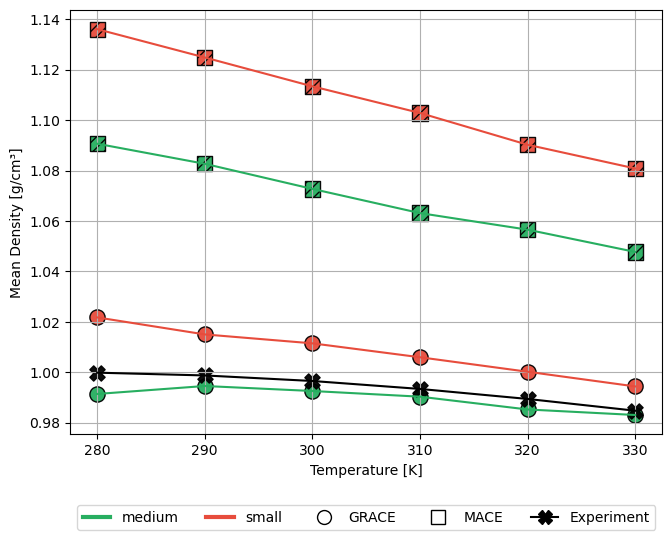

In [58]:
# --- Read the CSV ---
mean_data = pd.read_csv("temp_density/all_density_means.csv")

# --- Define styles for each column (except Temperature) ---
plot_styles = {
    "GRACE (2L-S)": {"color": size_colors["small"], "marker": marker_styles["grace"], "label": "GRACE (2L-S)"},
    "GRACE (2L-M)": {"color": size_colors["medium"], "marker": marker_styles["grace"], "label": "GRACE (2L-M)"},
    "MACE (S)": {"color": size_colors["small"], "marker": marker_styles["mace"], "label": "MACE (S)"},
    "MACE (M)": {"color": size_colors["medium"], "marker": marker_styles["mace"], "label": "MACE (M)"},
    "Experimental": {"color": "black", "marker": "X", "label": "Experimental Density"},
}

plt.figure(figsize=(7,5.5))

# --- Loop over columns to plot ---
for col, style in plot_styles.items():
    temps = mean_data["Temperature_K"]
    values = mean_data[col]
    
    plt.scatter(temps, values,
                color=style["color"],
                marker=style["marker"],
                edgecolor='k' if col != "Experimental" else None,
                s=120,
                label=style["label"],
                alpha=0.95,
                hatch='///' if 'MACE' in col else None)
    
    plt.plot(temps, values, color=style["color"])

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0],
           color=size_colors['medium'],
           label='medium',
           linewidth=3),
    Line2D([0], [0],
           color=size_colors['small'],
           label='small',
           linewidth=3),
    Line2D([0], [0],
           marker='o',
           color='w',
           label='GRACE',
           markerfacecolor='white',
           markeredgecolor='black',
           markersize=10),
    Line2D([0], [0],
           marker='s',
           color='w',
           label='MACE',
           markerfacecolor='white',
           markeredgecolor='black',
           markersize=10),
    Line2D([0], [0],
           marker='X',
           color='black',
           label='Experiment',
           markersize=10),
]

plt.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.15),
    fontsize=10,
    frameon=True
)

# --- Final plot formatting ---
plt.xticks([280, 290, 300, 310, 320, 330])
plt.xlabel('Temperature [K]')
plt.ylabel('Mean Density [g/cm³]')
plt.grid(True)

plt.tight_layout()
plt.savefig('density_vs_temperature.pdf')
plt.show()


/tmp/ipykernel_1297613/1351187809.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


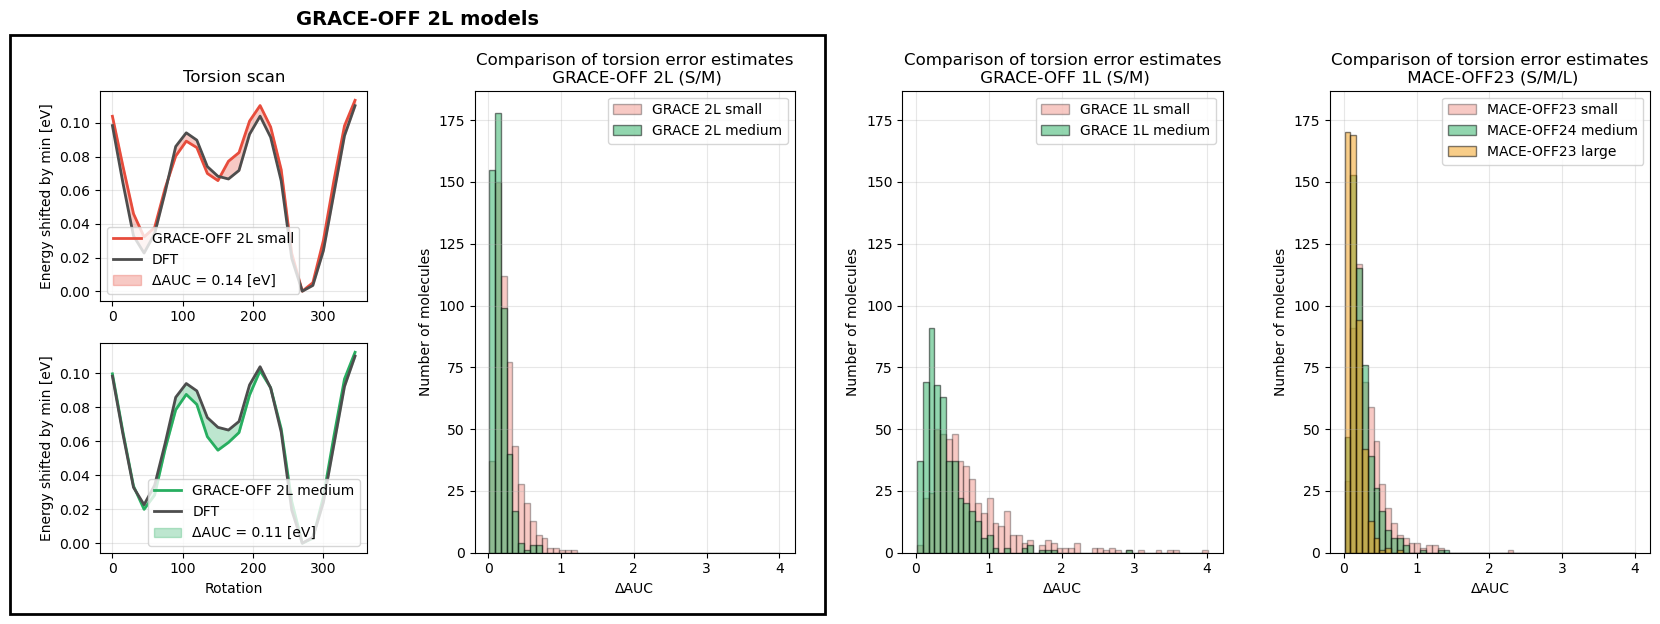

In [35]:
grace_errors_1l_off_s = pd.read_csv("torsion_scans/error_files/grace_errors_b_off_1l_small.csv")
grace_errors_1l_off_m = pd.read_csv("torsion_scans/error_files/grace_errors_b_off_1l_medium.csv")
grace_errors_2l_off_s = pd.read_csv("torsion_scans/error_files/grace_errors_b_off_2l_small.csv")
grace_errors_2l_off_m = pd.read_csv("torsion_scans/error_files/grace_errors_b_off_2l_medium.csv")

grace_errors_1l_wps_s = pd.read_csv("torsion_scans/error_files/grace_errors_a_wpS_1l_small.csv")
grace_errors_1l_wps_m = pd.read_csv("torsion_scans/error_files/grace_errors_a_wpS_1l_medium.csv")
grace_errors_2l_wps_s = pd.read_csv("torsion_scans/error_files/grace_errors_a_wpS_2l_small.csv")
grace_errors_2l_wps_m = pd.read_csv("torsion_scans/error_files/grace_errors_a_wpS_2l_medium.csv")

mace_errors_s = pd.read_csv("torsion_scans/error_files/mace_errors_small.csv")
mace_errors_m = pd.read_csv("torsion_scans/error_files/mace_errors_medium.csv")
mace_errors_l = pd.read_csv("torsion_scans/error_files/mace_errors_large.csv")


single_torsion = pd.read_csv("torsion_scans/single_torsion.csv")



# colors from above
color_small = size_colors["small"]   
color_medium = size_colors["medium"]  
color_large = size_colors["large"]    
color_dft = "#4d4d4d"    
data_tnet = h5py.File("../data/TNet500-SPICE.hdf5", "r")
smiles = list(data_tnet.keys())[0]



# prepare data for single torsion plot
torsion_small = np.asarray(single_torsion['small_2l']) - np.min(np.asarray(single_torsion['small_2l']))
torsion_med   = np.asarray(single_torsion['medium_2l']) - np.min(np.asarray(single_torsion['medium_2l']))
dft          = np.asarray(data_tnet[smiles]["dft total energy"]) * 27.211386245988
dft          = dft - np.min(dft)
x = np.arange(len(dft))

area_small = np.trapz(np.abs(torsion_small - dft), x)
area_medium= np.trapz(np.abs(torsion_med - dft), x)

x = np.arange(len(dft))*15

# Layout: 2 rows, 2 columns, right column wider
fig = plt.figure(figsize=(20, 6))
gs = GridSpec(
    2, 4,
    figure=fig,
    width_ratios=[1, 1.2, 1.2, 1.2],
    wspace=0.35   
)


# --- Left upper half: GRACE small vs DFT ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, torsion_small, color=color_small, label="GRACE-OFF 2L small", linewidth=2)
ax1.plot(x, dft, color=color_dft, label="DFT", linewidth=2)
ax1.fill_between(x, torsion_small, dft, color=color_small, alpha=0.3, label=f"ΔAUC = {area_small:.2f} [eV]")
ax1.set_ylabel("Energy shifted by min [eV]")
ax1.set_title("Torsion scan")# \n GRACE 2L small vs DFT")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Left lower half: GRACE medium vs DFT ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(x, torsion_med, color=color_medium, label="GRACE-OFF 2L medium", linewidth=2)
ax2.plot(x, dft, color=color_dft, label="DFT", linewidth=2)  
ax2.fill_between(x, torsion_med, dft, color=color_medium, alpha=0.3, label=f"ΔAUC = {area_medium:.2f} [eV]")
ax2.set_xlabel("Rotation")
ax2.set_ylabel("Energy shifted by min [eV]")
ax2.legend()
ax2.grid(True, alpha=0.3)


# Shared x and y labels for left side
x_min = min(np.min(grace_errors_1l_off_s['AUC']), np.min(grace_errors_1l_off_m['AUC']),
            np.min(grace_errors_2l_off_s['AUC']), np.min(grace_errors_2l_off_m['AUC']))
x_max = max(np.max(grace_errors_1l_off_s['AUC']), np.max(grace_errors_1l_off_m['AUC']),
            np.max(grace_errors_2l_off_s['AUC']), np.max(grace_errors_2l_off_m['AUC']))

bar_width = 0.08  # Barwidth for histogram
bins = np.arange(x_min, x_max + bar_width, bar_width)  # boundaries for histogram bins

# --- Right side (over two rows): Histogram ---
ax3 = fig.add_subplot(gs[:, 1])
ax3.hist(grace_errors_2l_off_s['AUC'], bins=bins, color=color_small, edgecolor='black', alpha=0.3, label='GRACE 2L small')
ax3.hist(grace_errors_2l_off_m['AUC'], bins=bins, color=color_medium, edgecolor='black', alpha=0.5, label='GRACE 2L medium')
ax3.set_xlabel("ΔAUC")
ax3.set_ylabel("Number of molecules")
ax3.set_title("Comparison of torsion error estimates\n GRACE-OFF 2L (S/M)")
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[:, 2], sharex=ax3, sharey=ax3)
ax4.hist(grace_errors_1l_off_s['AUC'], bins=bins, color=color_small, edgecolor='black', alpha=0.3, label='GRACE 1L small')
ax4.hist(grace_errors_1l_off_m['AUC'], bins=bins, color=color_medium, edgecolor='black', alpha=0.5, label='GRACE 1L medium')
ax4.set_xlabel("ΔAUC")
ax4.set_ylabel("Number of molecules")
ax4.set_title("Comparison of torsion error estimates\n GRACE-OFF 1L (S/M)")
ax4.legend()
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[:, 3], sharex=ax3, sharey=ax3)
ax5.hist(mace_errors_s['AUC'], bins=bins, color=color_small, edgecolor='black', alpha=0.3, label='MACE-OFF23 small')
ax5.hist(mace_errors_m['AUC'], bins=bins, color=color_medium, edgecolor='black', alpha=0.5, label='MACE-OFF24 medium')
ax5.hist(mace_errors_l['AUC'], bins=bins, color=color_large, edgecolor='black', alpha=0.5, label='MACE-OFF23 large')
ax5.set_xlabel("ΔAUC")
ax5.set_ylabel("Number of molecules")
ax5.set_title("Comparison of torsion error estimates\n MACE-OFF23 (S/M/L)")
ax5.legend()
ax5.grid(True, alpha=0.3)



# Force rendering so text positions are known
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

group_axes = [ax1, ax2, ax3]

# Get tight bounding boxes (including labels)
bboxes = [ax.get_tightbbox(renderer).transformed(fig.transFigure.inverted())
          for ax in group_axes]

xmin = min(bb.x0 for bb in bboxes)
ymin = min(bb.y0 for bb in bboxes)
xmax = max(bb.x1 for bb in bboxes)
ymax = max(bb.y1 for bb in bboxes)

# Padding in figure coordinates
pad_x = 0.015
pad_y = 0.03

rect = Rectangle(
    (xmin - pad_x, ymin - pad_y),
    (xmax - xmin) + 2 * pad_x,
    (ymax - ymin) + 2 * pad_y,
    transform=fig.transFigure,
    fill=False,
    linewidth=2,
    edgecolor='black'
)

fig.add_artist(rect)

fig.text(
    (xmin + xmax) / 2,
    ymax + pad_y + 0.01,
    "GRACE-OFF 2L models",
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold"
)


plt.tight_layout()
plt.show()
